# LangGraph를 사용한 고객 지원 챗봇을 구축

- 웹 검색을 통해 일반적인 질문에 답변 
- 대화 상태를 유지하여 연속적인 대화  
- 복잡한 질문을 사람이 검토하도록 라우팅  
- 사용자 지정 상태(Custom State)를 활용하여 챗봇의 동작 제어  
- 대화 흐름을 되돌리고(Rewind), 다른 대화 경로 탐색 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# LangSmith 추적 설정 활성화
os.environ["LANGSMITH_TRACING"] = "true"

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

먼저 모델을 직접 사용해 봅니다. `ChatModel`은 LangChain의 **"Runnable"** 인스턴스이며, 이는 표준화된 인터페이스를 통해 상호작용할 수 있음을 의미합니다.  

모델을 간단하게 호출하려면 `.invoke` 메서드에 **메시지 목록**을 전달하면 됩니다.

In [4]:
from langchain_core.messages import HumanMessage

response = llm.invoke([HumanMessage(content="안녕! 나는 길동이야.")])
response.content

'안녕, 길동! 만나서 반가워. 어떻게 지내고 있어?'

모델 자체는 **상태(state)** 라는 개념을 가지고 있지 않습니다. 예를 들어, 후속 질문을 하면:

In [5]:
response = llm.invoke([HumanMessage(content="내 이름이 뭐라고 했지?")])
response.content

'죄송하지만, 당신의 이름을 알 수 있는 정보가 없습니다. 당신의 이름을 말씀해 주시면 기억하겠습니다!'

In [6]:
from langchain_core.messages import AIMessage

response = llm.invoke(
    [
        HumanMessage(content="안녕! 나는 길동이야."),
        AIMessage(content="안녕하세요, 길동님. 무엇을 도와 드릴까요?"),
        HumanMessage(content="내 이름이 뭐라고 했지?"),
    ]
)

response.content

'길동님이라고 하셨습니다! 어떻게 도와드릴까요?'

<br>
이제 좋은 응답을 받는 것을 확인할 수 있습니다!  

이것이 챗봇이 **대화형 상호작용**을 할 수 있는 기본 아이디어입니다.  

### **Part 1: 기본 챗봇 만들기¶**  

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages

# MessageState를 기반으로 그래프를 구성하기 위한 graph_builder 설정
graph_builder = StateGraph(state_schema=MessagesState)

다음으로 **"chatbot" 노드**를 추가합니다.  
**노드(Nodes)** 는 작업의 단위를 나타내며, 일반적으로 **일반적인 Python 함수**로 구성됩니다. 

In [8]:
# 챗봇 함수 정의
def chatbot(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}

# 첫 번째 인자는 노드의 고유한 이름 ("chatbot")
# 두 번째 인자는 노드가 실행될 때 호출될 함수 또는 객체
graph_builder.add_node("chatbot", chatbot)

- 챗봇 노드 함수는 **현재 상태(State)를 입력**으로 받고, **업데이트된 메시지 리스트**를 `"messages"` 키에 담아 **딕셔너리 형태로 반환**합니다.  
- 이 패턴은 **모든 LangGraph 노드 함수의 기본 구조**입니다.  

**다음 단계:**  
- **엔트리 포인트(Entry Point)** 를 추가  
- **엔트리 포인트**는 **그래프 실행 시 시작 지점을 정의**하며, **매번 그래프를 실행할 때 어디서부터 작업을 시작할지 지정하는 역할**을 합니다.
- 마찬가지로, **종료 지점(Finish Point)** 을 설정합니다. 이는 그래프에게 **"이 노드가 실행될 때마다, 여기서 작업을 종료할 수 있다."** 라고 지시하는 역할을 합니다.
- 마지막으로, 그래프를 실행할 수 있도록 설정해야 합니다. 이를 위해 **`compile()`** 메서드를 그래프 빌더에서 호출합니다.   

In [9]:
graph_builder.add_edge(START, "chatbot")

graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

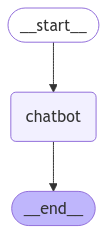

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### **챗봇 실행**  

대화 루프에서 언제든지 **"quit"**, **"exit"**, 또는 **"q"** 를 입력하면 종료할 수 있습니다. 

In [11]:
def stream_graph_updates(user_input: str):
    """
    그래프를 스트리밍 방식으로 업데이트하는 함수
    사용자 입력을 받아, LLM이 응답하는 과정을 streaming 방식으로 출력
    """
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):  
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)  # 최신 응답 메시지를 출력


# 무한 루프 (사용자가 "quit", "exit", "q"를 입력하면 종료)
while True:
    try:
        user_input = input("사용자: ")  
        if user_input.lower() in ["quit", "exit", "q"]: 
            print("종료합니다.") 
            break

        stream_graph_updates(user_input) 
    except:
        # `input()`이 사용 불가능한 경우 예외 처리 (예: 특정 환경에서 실행 시)
        user_input = "LangGraph 에 대해 말해줘."  
        print("사용자: " + user_input)
        stream_graph_updates(user_input)  
        break  

사용자:  안녕


Assistant: 안녕하세요! 무엇을 도와드릴까요?


사용자:  q


종료합니다.


LangGraph를 사용하여 첫 번째 챗봇을 구축 했습니다.  

다음 단계에서는 웹 검색 도구를 추가하여 챗봇의 지식을 확장하고, 더 강력한 기능을 갖추도록 만들겠습니다. 

## **Part 2: 도구를 활용한 챗봇 강화**   
이제 챗봇이 **웹에서 관련 정보를 찾아 더 나은 답변을 제공할 수 있도록 개선**합니다. 

---
먼저 **Tavily 검색 엔진**을 사용하기 위해 필요한 패키지를 설치하고 **`TAVILY_API_KEY`** 를 설정 합니다.  

In [12]:
# %%capture --no-stderr
# %pip install -U tavily-python langchain_community

In [13]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("LangGraph에서 node가 뭐야?")

[{'title': '1-3-3. 노드 (Node) - LangGraph 가이드북 - 위키독스',
  'url': 'https://wikidocs.net/261580',
  'content': '노드 (Node) - LangGraph 가이드북 - 에이전트 RAG with 랭그래프 LangGraph 가이드북 - 에이전트 RAG with 랭그래프 Part 0. 랭그래프 LangGraph 기초 1-1. 랭그래프 LangGraph 소개 1-1-1.LangGraph의 개념과 특징 1-1-2. LangGraph 환경 설정 및 기본 사용법 1-2-1. LangGraph 설치 및 환경 구성 1-2-2. 노드 (Node) 1-3-4. 그래프 연결 및 실행 1-4. 조건부 라우팅 구현 1-4-1. 조건부 엣지 정의 방법 1-4-3. 상태 저장 및 복원 예제 1-6. LangGraph 가이드북 - 에이전트 RA… 랭그래프 LangGraph 기초 노드 (Node) 노드 (Node) LangGraph의 노드(Node) 이해하기 graph.add_node("increment", increment) 2. 그래프에 노드 추가: graph.add_node("increment", increment) 상태 처리: 노드는 현재 상태를 받아 필요한 작업을 수행합니다. Report a comment. Do you want to report this comment? Report a comment is available for the following situations:',
  'score': 0.8080827},
 {'title': 'LangGraph) LangGraph에 대한 개념과 간단한 예시 만들어보기',
  'url': 'https://data-newbie.tistory.com/997',
  'content': 'from langgraph.graph import END, StateGraph return {**state, "data": df, "target": target, "params": 

결과는 **페이지 요약(Summaries)** 으로, **챗봇이 질문에 답변할 때 사용할 수 있습니다.**  

다음 코드는 **Part 1과 동일하지만, 한 가지 차이가 있습니다.**  

**LLM에 `bind_tools`를 추가하여, LLM이 검색 엔진을 사용할 때 올바른 JSON 형식을 인식하도록 설정했습니다.** 

In [14]:
graph_builder = StateGraph(MessagesState)

# 수정 사항: LLM이 사용할 수 있는 도구(Tools)를 명시적으로 설정
llm_with_tools = llm.bind_tools(tools) 

# 챗봇 함수 정의
def chatbot(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}  

graph_builder.add_node("chatbot", chatbot)  

이제 도구가 호출되었을 때 실제로 실행하는 함수를 만들어야 합니다. 이를 위해 새로운 노드(node)를 추가하여 도구를 실행할 수 있도록 설정합니다.

이 노드는 Anthropic, OpenAI, Google Gemini 등 여러 LLM 제공업체에서 지원하는 **`tool_calling` 기능**을 활용합니다.  

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition

# "tools" 노드 생성 및 그래프에 추가
tool_node = ToolNode(tools=[tool])  
graph_builder.add_node("tools", tool_node)  

**조건부 엣지(Conditional Edges)의 동작 방식**  

- 조건부 엣지는 특정 노드에서 시작됩니다. 즉, 'chatbot' 노드가 실행될 때마다, 다음과 같은 경로를 결정합니다.

1️) 만약 챗봇이 도구(`tool_calls`)를 호출하면 'tools' 노드로 이동   
2️) 만약 챗봇이 직접 응답하면 `END`로 이동하여 실행 종료


**`tools_condition`**  

- **`tool_calls`가 없는 경우 `END` 문자열을 반환하여 실행을 종료** 합니다.  

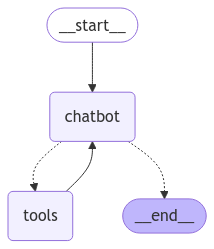

In [16]:
graph_builder.add_conditional_edges(
    "chatbot",  
    tools_condition,
)

# 도구 사용이 완료되면 다시 챗봇 노드로 돌아가서 다음 단계 결정
graph_builder.add_edge("tools", "chatbot")

# 그래프의 시작점 정의 (START → chatbot)
graph_builder.add_edge(START, "chatbot")

# 그래프 컴파일 (최종 그래프 생성)
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇에게 **훈련 데이터에 없는 질문도 할 수 있습니다.** 

In [17]:
while True:
    try:
        user_input = input("사용자: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("종료합니다.")
            break

        stream_graph_updates(user_input)
    except:
        user_input = "LangGraph에 대해 알고 있는 것을 말해줘."
        print("사용자: " + user_input)
        stream_graph_updates(user_input)
        break

사용자:  안녕


Assistant: 안녕하세요! 어떻게 도와드릴까요?


사용자:  Langchain v0.3 출시일


Assistant: 
Assistant: [{"title": "Announcing LangChain v0.3", "url": "https://blog.langchain.dev/announcing-langchain-v0-3/", "content": "Announcing LangChain v0.3. 2 min read Sep 16, 2024. Today, we're excited to announce the release of LangChain v0.3", "score": 0.8335554}, {"title": "LangChain v0.3", "url": "https://js.langchain.com/docs/versions/v0_3/", "content": "How to use few shot examples in chat models How to add ad-hoc tool calling capability to LLMs and Chat Models How to use chat models to call tools How to pass tool outputs to chat models How to use LangChain tools How to use few-shot prompting with tool calling Why LangChain? LangChain v0.3 | langchain | 0.3.0 | >\\=0.3.0 <0.4.0 | | @langchain/community | 0.3.0 | >\\=0.3.0 <0.4.0 | | @langchain/core | 0.3.0 | >\\=0.3.0 <0.4.0 | | @langchain/langgraph | 0.2.3 | >\\=0.2.3 <0.3 | yarn add @langchain/core pnpm add @langchain/core process.env.LANGCHAIN_CALLBACKS_BACKGROUND = \"false\";const startTimeBlocking = new Date().getT

사용자:  q


종료합니다.


이제 LangGraph에서 검색 엔진을 활용할 수 있는 대화형 에이전트(Conversational Agent)를 만들었습니다

--- 

## **Part 3: 챗봇에 메모리 기능 추가¶**  

현재 챗봇은 **사용자 질문에 도구를 활용해 답변할 수 있지만, 이전 대화의 맥락을 기억하지 못합니다.**  
이 때문에 **일관된 멀티턴(Multi-turn) 대화를 진행하는 데 한계가 있습니다.**  

LangGraph는 **"지속적 체크포인트(Persistent Checkpointing)"** 기능을 통해 이 문제를 해결합니다.  

그래프를 컴파일할 때 checkpointing을 활성화하고 그래프를 호출할 때 `thread_id`를 제공하면, LangGraph가 자동으로 상태(state)를 저장하고, 다음 실행 시 이전 상태를 복원합니다.  

즉, **동일한 `thread_id`** 를 사용하여 그래프를 호출하면, 이전 대화 상태를 불러와서 이어서 대화할 수 있습니다!

In [18]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

우리는 현재 **메모리를 활용하는(in-memory) 체크포인터**를 사용하고 있습니다.  

이 방식은 튜토리얼 환경에서는 편리하지만, 데이터가 메모리에만 저장되므로 영구적이지 않습니다. 실제 프로덕션 환경에서는 `SqliteSaver` 또는 `PostgresSaver`를 사용하여 데이터베이스(DB)와 연결하는 것이 일반적입니다.

---

## **그래프 정의**

In [19]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(MessagesState)

tool = TavilySearchResults(max_results=2)
tools = [tool]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# # 도구가 호출될 때마다, 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 제공된 체크포인터와 함께 그래프를 컴파일
graph = graph_builder.compile(checkpointer=memory)

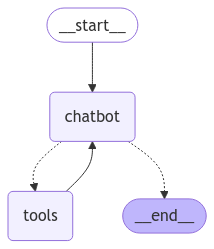

In [20]:
display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇과 상호작용할 수 있습니다. 먼저, 이 대화를 식별할 수 있는 **`thread`(스레드)** 를 선택합니다.

In [21]:
config = {"configurable": {"thread_id": "1"}}

user_input = "안녕하세요! 제 이름은 길동이에요."

# config는 stream() 또는 invoke()의 두 번째 인자
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 길동이에요.
================================== Ai Message ==================================

안녕하세요, 길동님! 어떻게 도와드릴까요?


이제 후속 질문(follow-up question)을 해봅시다. 챗봇이 사용자의 이름을 기억하는지 확인해 봅니다.

In [22]:
user_input = "내 이름이 뭐야?"

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름이 뭐야?
================================== Ai Message ==================================

길동님이라고 하셨습니다! 다른 질문이나 필요한 정보가 있으신가요?


In [23]:
# `thread_id`를 "1" 대신 "2"로 변경합니다.
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름이 뭐야?
================================== Ai Message ==================================

죄송하지만, 당신의 이름을 알 수 있는 방법이 없습니다. 다른 질문이나 도움이 필요하신 부분이 있다면 말씀해 주세요!


---
지금까지 두 개의 서로 다른 thread에서 여러 개의 체크포인트를 생성했습니다. 체크포인트에는 어떤 정보가 저장되는 정보는 다음과 같습니다. 

- 현재 상태 값(Current State Values) 
- 해당 상태와 연결된 `config` 정보  
- 다음으로 처리할 노드(Next Node to Process) 

In [24]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='안녕하세요! 제 이름은 길동이에요.', additional_kwargs={}, response_metadata={}, id='fc5c0640-c2b9-455c-9201-83750a5c461a'), AIMessage(content='안녕하세요, 길동님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 90, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_06737a9306', 'finish_reason': 'stop', 'logprobs': None}, id='run-2ede216e-e118-42bb-9e1a-d4dd4db85c3e-0', usage_metadata={'input_tokens': 90, 'output_tokens': 16, 'total_tokens': 106, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content='내 이름이 뭐야?', additional_kwargs={}, response_metadata={}, id='0

In [25]:
# 현재 상태 값
snapshot.values

{'messages': [HumanMessage(content='안녕하세요! 제 이름은 길동이에요.', additional_kwargs={}, response_metadata={}, id='fc5c0640-c2b9-455c-9201-83750a5c461a'),
  AIMessage(content='안녕하세요, 길동님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 90, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_06737a9306', 'finish_reason': 'stop', 'logprobs': None}, id='run-2ede216e-e118-42bb-9e1a-d4dd4db85c3e-0', usage_metadata={'input_tokens': 90, 'output_tokens': 16, 'total_tokens': 106, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='내 이름이 뭐야?', additional_kwargs={}, response_metadata={}, id='0e902faf-19e3-476b

In [26]:
# 해당 상태와 관련된 config 정보
snapshot.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1effe3c0-007e-6225-8004-9b15076beff3'}}

In [27]:
# 다음으로 처리할 node
snapshot.next

()

### 프롬프트 템플릿(Prompt Templates)을 사용하여 LLM 호출 최적화

**프롬프트 템플릿** 은 **원시 사용자 입력(raw user input)** 을 LLM이 처리할 수 있는 형식으로 변환하는 데 도움을 줍니다.   

1. 먼저, **시스템 메시지(system message)** 를 추가하여 **사용자 정의 지침(custom instructions)** 을 포함시킵니다. (여전히 메시지를 입력으로 사용)  
2. 다음으로, 메시지 외에 **더 많은 입력 정보** 를 추가합니다.  

#### **시스템 메시지(System Message) 추가하기**

시스템 메시지를 추가하기 위해 **`ChatPromptTemplate`** 을 생성합니다. 여기서는 메시지 전달을 위해 **`MessagesPlaceholder`** 를 사용하겠습니다.  

이렇게 하면 LLM에 전달되는 입력이 더 구조화되고, 챗봇의 동작을 더 정교하게 제어할 수 있습니다.  

In [28]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# LLM이 사용자 입력을 더 잘 처리할 수 있도록 프롬프트 템플릿을 설정합니다.
prompt_template = ChatPromptTemplate.from_messages(
    [
        # LLM의 동작 방식을 정의하는 지침
        (
            "system",
            "당신은 친구 처럼 말합니다. 모든 질문에 최선을 다해 대답하세요.",
        ),

        # Messages Placeholder - 이전 대화 메시지들을 전달합
        MessagesPlaceholder(variable_name="messages"),
    ]
)

이제 이 템플릿을 통합하여 애플리케이션을 업데이트할 수 있습니다.

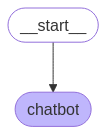

In [29]:
graph_builder = StateGraph(state_schema=MessagesState)

# 모델 호출 함수 정의
def chatbot(state: MessagesState):
    prompt = prompt_template.invoke(state)   # 현재 상태(state)를 기반으로 프롬프트를 생성
    response = llm.invoke(prompt)        # 생성된 프롬프트를 LLM에 전달하여 응답 생성
    return {"messages": response}   # 모델의 응답을 딕셔너리 형태로 반환

graph_builder.add_node("chatbot", chatbot)

# START에서 "chatbot" 노드로 이동하도록 엣지 정의
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()

# 그래프를 메모리 체크포인트와 함께 컴파일합니다.
graph = graph_builder.compile(checkpointer=memory)
graph

In [30]:
# 'configurable' 키를 사용하여 추가적인 설정 값을 전달합니다.
# 여기서는 'thread_id'를 사용하여 특정 대화 스레드를 식별합니다.
config = {"configurable": {"thread_id": "abc345"}}

# 메시지 목록에 사용자 메시지 추가
input_messages = [HumanMessage("안녕.")]

# 애플리케이션 호출
# 메시지 상태(State), 설정(config) 전달
output = graph.invoke({"messages": input_messages}, config)

output["messages"][-1].pretty_print()

================================== Ai Message ==================================

안녕! 어떻게 지내? 요즘 뭐 하고 지내?


## **Part 4: 인간 개입**

작업을 성공적으로 수행하려면 **사람의 입력(human input)** 이 필요할 수도 있습니다.  
또한, 특정 작업을 실행하기 전에 **사람의 승인(human approval)** 을 요구하여 올바르게 동작하는지 확인하고 싶을 수도 있습니다.  

---

## **LangGraph의 Human-in-the-loop 지원**  
LangGraph의 **영속성 계층(persistence layer)** 은 **"Human-in-the-loop" 워크플로우** 를 지원합니다.  
이를 통해 **실행을 일시 중지(pause)하고, 사용자 피드백을 기반으로 다시 실행(resume)** 할 수 있습니다.  

In [31]:
from langchain_core.tools import tool

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearchResults(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # 도구 실행 중에 중단이 발생하므로
    # 재개할 때 도구 호출이 반복되지 않도록 병렬 도구 호출을 비활성화합니다.
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [32]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

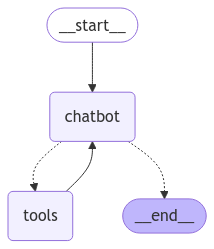

In [33]:
display(Image(graph.get_graph().draw_mermaid_png()))

이제 새로운 human_assistance 도구를 사용할 수 있는 질문을 챗봇에 입력해 보겠습니다.

In [34]:
user_input = "AI 에이전트를 만드는 데 전문가의 지침이 필요합니다. 도움을 요청해 주시겠습니까?"

config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

AI 에이전트를 만드는 데 전문가의 지침이 필요합니다. 도움을 요청해 주시겠습니까?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_BWcwlor50SJazZtBKs9OMJL3)
 Call ID: call_BWcwlor50SJazZtBKs9OMJL3
  Args:
    query: AI 에이전트를 만드는 방법에 대한 전문가의 지침
================================= Tool Message =================================
Name: human_assistance

Error: NameError("name 'interrupt' is not defined")
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_fA2nbHmHKERGm5E4IUnCLgHe)
 Call ID: call_fA2nbHmHKERGm5E4IUnCLgHe
  Args:
    query: AI 에이전트를 만드는 방법에 대한 전문가의 지침 요청
================================= Tool Message =================================
Name: human_assistance

Error: NameError("name 'interrupt' is not defined")
 Please fix your mistakes.
================================== Ai 

--------------------
챗봇이 도구 호출을 생성했지만 실행이 중단되었습니다! 그래프 상태를 검사하면 도구 노드에서 멈췄음을 알 수 있습니다.

In [35]:
snapshot = graph.get_state(config)
snapshot.next

()

Python의 내장 input() 함수와 유사하게, 도구 내부에서 interrupt를 호출하면 실행이 일시 중지됩니다. 

실행을 재개하려면 도구에서 예상하는 데이터가 포함된 Command 객체를 전달합니다. 이 데이터의 형식은 필요에 따라 사용자 정의할 수 있습니다. 여기서는 "data" 키가 있는 dict만 있으면 됩니다.

In [36]:
from langgraph.types import Command

human_response = (
    "저희, 전문가들이 도와드리겠습니다! 에이전트를 빌드하려면 LangGraph를 확인해보시기를 권장합니다."
    "단순 자율 에이전트보다 훨씬 더 안정적이고 확장 가능합니다."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

AI 에이전트를 만드는 방법에 대한 유용한 자료를 찾았습니다. 아래의 링크와 내용을 확인해 보세요:

1. **[더 나은 자동화를 위해 AI 에이전트를 구축하는 방법 - ClickUp](https://clickup.com/ko/blog/263202/how-to-build-an-ai-agent)**  
   이 글에서는 AI 에이전트를 통해 작업 및 프로젝트 관리 요구에 어떻게 효율적으로 대응할 수 있는지 설명합니다. 데이터 과학자, UX 디자이너, 머신러닝 및 소프트웨어 개발 전문가와 함께 맞춤형 AI 에이전트를 구축할 수 있는 방법도 소개하고 있습니다.

2. **[초보자를 위한 AI 에이전트 구축 방법 (2025) - Botpress](https://botpress.com/ko/blog/build-ai-agent)**  
   이 블로그 포스트는 AI 에이전트를 구축하는 방법에 대한 기초적인 가이드를 제공합니다. 플랫폼 선택에서 시작하여, 자율 노드를 사용하여 AI 에이전트를 어떻게 설계할 수 있는지에 대한 팁을 포함하고 있습니다.

이 자료들을 참고하시면 AI 에이전트를 만드는 데 필요한 기초 지식과 실용적인 정보를 얻을 수 있습니다. 추가적인 질문이 있으시면 언제든지 말씀해 주세요!


-----------------
인터럽트를 사용하여 채팅봇에 인간 참여 루프 실행을 추가하여 필요할 때 인간의 감독과 개입을 허용했습니다. 이를 통해 AI 시스템으로 만들 수 있는 잠재적인 UI가 열립니다. 이미 체크포인터를 추가했으므로 기본 지속성 계층이 실행되는 한 그래프를 무기한 일시 중지하고 아무 일도 없었던 것처럼 언제든지 다시 시작할 수 있습니다.